# Accessing CLMS data via Copernicus Data Space Ecosystem (Module 2)

This notebook is a hands-on introduction to the **Copernicus Data Space Ecosystem (CDSE) Sentinel Hub APIs** using CLMS data. It is built around the following use-case: **Zero Pollution monitoring**, specifically how landscape composition explains nitrate concentrations in European surface waters.

In this example workflow, three **Copernicus Land Monitoring Service (CLMS)** High-Resolution Layers act as predictors of nitrate dynamics:

- **Tree Cover Density (TCD)**: areas with high tree cover (typically ≥ 75 %) act as a proxy for runoff mitigation and nitrate retention by riparian vegetation.
- **Crop Types**: used to identify and quantify the percentage of different crop types within the area of influence.
- **LCM-10 (Land Cover Map at 10 m, Global, Annual V1)**: used to characterise non‑agricultural land cover classes (e.g. shrubs, forests, herbaceous vegetation) surrounding monitoring stations.

These indicators are then used as fixed-effect predictors in a linear mixed-effects model. **This notebook stops at the indicator-extraction stage**. We will not do any statistical modelling here.

## Learning objectives

By the end of this notebook you will be able to:

- Authenticate against the CDSE Sentinel Hub APIs using OAuth client credentials.
- Load an Area of Interest (AOI) as a polygon from a GeoJSON file (in any CRS supported by Sentinel Hub).
- Fetch a CLMS **BYOC (Bring Your Own COG)** raster for that AOI using the **Process API**.
- Visualise the raster.
- Compute area-percentage statistics on the server-side via the **Statistical API**.
- Adapt the workflow to your own AOIs / products.

## Prerequisites

- A free **CDSE account** at https://dataspace.copernicus.eu/.
- **OAuth client credentials** (a client ID and client secret) generated from the CDSE Sentinel Hub Dashboard at https://shapps.dataspace.copernicus.eu/dashboard/.
- The Python packages `sentinelhub`, `geopandas`, `shapely`, `folium`, `matplotlib`, `pandas`, and `numpy`. If you set up this repository with `uv sync`, they are already installed.

## Outline

1. Setup and authentication
2. Defining an Area of Interest
3. Define the CLMS collections (BYOC)
4. Fetch the Tree Cover Density raster (Process API)
5. Fetch the Crop Types raster (Process API)
6. Compute area statistics with the Statistical API
7. Crop Type area percentages from the raster
8. Fetch non-agricultural land cover (LCM-10)
9. Recap: all CLMS-derived indicators on one chart
10. Try it yourself


## 1. Setup and Authentication

Sentinel Hub uses **OAuth 2.0 client credentials** for authentication. In practice this means you generate a `client_id` and a `client_secret` once in the CDSE Sentinel Hub Dashboard, and the `sentinelhub` Python library uses them behind the scenes to obtain short-lived **access tokens** for each API call. You never have to manage tokens yourself.

You can create or retrieve your credentials at the CDSE Sentinel Hub Dashboard: https://shapps.dataspace.copernicus.eu/dashboard/. Look for the *User Settings* section and create a new OAuth client.

We load these credentials from **environment variables** rather than hard-coding them. This is a basic security practice: secrets in source files often end up committed to version control by accident, while environment variables stay on the machine that runs the code.

Two service URLs matter here:

- `sh_token_url` — the endpoint that exchanges your client credentials for an access token.
- `sh_base_url` — the base URL for all Sentinel Hub API calls.


The next cell loads the credentials, configures the `SHConfig` object, and verifies that everything is in place.


In [1]:
# Setup: imports, Sentinel Hub config, and CDSE authentication.
import json
from pathlib import Path

import folium
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from shapely.geometry import shape
from sentinelhub import (
    CRS,
    DataCollection,
    Geometry,
    MimeType,
    SentinelHubRequest,
    SentinelHubStatistical,
    SHConfig,
    bbox_to_dimensions,
)

In [ ]:
# CDSE service endpoints.
config = SHConfig()
#config.sh_client_id = ""
#config.sh_client_secret = ""
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

print("Sentinel Hub config ready.")
print(f"  token_url: {config.sh_token_url}")
print(f"  base_url:  {config.sh_base_url}")
print(f"  client_id set: {bool(config.sh_client_id)}")
print(f"  client_secret set: {bool(config.sh_client_secret)}")

Sentinel Hub config ready.
  token_url: https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token
  base_url:  https://sh.dataspace.copernicus.eu
  client_id set: True
  client_secret set: True


## 2. Define an Area of Interest

Sentinel Hub accepts an AOI either as a **bounding box** or a **polygon**. For environmental monitoring use-cases a polygon is often more flexible, as a user may want to provide an input area as a station catchment, a protected-area boundary, or an upstream-flow buffer in GeoJSON format.

For this demo we load a polygon around **Lake Serre-Ponçon in the French Alps** (Hautes-Alpes, France) from a GeoJSON file shipped next to this notebook (`data/serre_poncon_3035.geojson`). You can explore a recent Sentinel-2 image of the lake in the [Copernicus Browser](link.dataspace.copernicus.eu/ev6e).

Lac de Serre-Ponçon is a voluminous artificial reservoir located in the French Alps, formed by the Durance and Ubaye rivers. Holding a maximum capacity of approximately 1.27 billion cubic meters of water, the lake exhibits pronounced seasonal hydrological variations driven primarily by alpine snowmelt and regional precipitation patterns. Consequently, this controlled aquatic environment provides a highly relevant geographical baseline for scientific investigations into watershed management, sediment transport dynamics, and the ecological impacts of large-scale river flow regulation.

A note on **CRS**: the GeoJSON is in **EPSG:3035** (ETRS89 / LAEA Europe), the standard equal-area projection for pan-European analyses. Sentinel Hub accepts a `Geometry` together with its CRS. Working in a metric CRS like EPSG:3035 also makes resolutions intuitive, as they are defined in the unit of the project: `resolution=(10, 10)` represents 10 metres per pixel.

In [8]:
# Load the Serre Ponçon AOI polygon (EPSG:3035 / LAEA Europe) from disk.
aoi_path = Path("data/serre_poncon_3035.geojson")
aoi_polygon = shape(json.loads(aoi_path.read_text(encoding="utf-8")))

# Wrap as a Sentinel Hub `Geometry` together with its CRS.
AOI_GEOMETRY = Geometry(aoi_polygon, crs=CRS("3035"))

# The bounding rectangle (in EPSG:3035, metres) determines output raster
# dimensions. Pixels outside the polygon will come back with dataMask=0.
AOI_BBOX = AOI_GEOMETRY.bbox

print("AOI: Serre Ponçon (Hautes-Alpes, France)")
print("  CRS:                EPSG:3035 (LAEA Europe, units = metres)")
print(f"  area:               {aoi_polygon.area / 1e6:.2f} km^2")
print(f"  bounding rectangle: {tuple(round(v, 1) for v in AOI_BBOX)}")

# Reproject to WGS84 for the Folium preview map.
aoi_geom_wgs = AOI_GEOMETRY.transform(CRS.WGS84)
center_lon, center_lat = aoi_geom_wgs.geometry.centroid.coords[0]

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")
folium.GeoJson(
    aoi_geom_wgs.geometry.__geo_interface__,
    name="AOI",
    style_function=lambda _: {"color": "red", "weight": 2, "fillOpacity": 0.1},
    tooltip="Serre Ponçon AOI",
).add_to(m)
m

AOI: Serre Ponçon (Hautes-Alpes, France)
  CRS:                EPSG:3035 (LAEA Europe, units = metres)
  area:               7.38 km^2
  bounding rectangle: (4040549.4, 2388143.4, 4045018.7, 2391900.1)


## 3. Define the CLMS Collections (BYOC)

**BYOC** stands for *Bring Your Own COG* (Cloud-Optimised GeoTIFF). It is the mechanism by which Sentinel Hub exposes datasets that are not part of the standard Sentinel mission archive. CLMS publishes its products as COGs on CDSE object storage; each product is registered as a BYOC collection identified by a UUID `collection_id`. Once registered, anyone with a CDSE account can query the collection through the standard Sentinel Hub APIs — Process, Statistical, Catalog, or Batch, exactly like a built-in dataset.

### Where to find collection IDs

The official catalogue of CLMS collections available on CDSE Sentinel Hub lives at:

> **https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/CLMS.html**

That page is an index, organised by product family (vegetation, land cover, water, snow, …). To get the `collection_id` for a specific product:

1. Open the index page above and navigate to the product family (e.g. *Land Cover and Land Use Mapping → Tree Cover and Forests*).
2. Click through to the dataset's own page (e.g. *TCD 10m Yearly (2018-present)*).
3. The dataset page lists each available collection (main layer + confidence layer, where applicable) in a two-column table. The right-hand column is the UUID you need.
4. To use a UUID in a Sentinel Hub API request, prepend `byoc-`. In Python with the `sentinelhub` package, pass it directly to `DataCollection.define_byoc(collection_id, name=...)`.

### Collections used in this notebook

- **High-Resolution Layer Tree Cover Density (TCD)** — see [the product page on CDSE docs](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/clms/land-cover-and-land-use-mapping/tree-cover-and-forests/tree-cover-density/tree-cover-density/clms_vlcc_tree-cover-density_europe_10m_yearly_v1.html).
  - `collection_id`: `3751d55a-7370-4071-9543-493ec3341d16`
  - Band: `TCD`, integer percentage `0–100` (proportion of pixel covered by tree canopy).
  - Native resolution: 10 m.

- **High-Resolution Layer Crop Types** — see [the product page on CDSE docs](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/clms/land-cover-and-land-use-mapping/croplands/crop-types/crop-types/clms_vlcc_crop-types_europe_10m_yearly_v1.html).
  - `collection_id`: `4fa71893-371f-4440-97c4-917f569f67b2`
  - Band: `CTY`, integer class codes for 19 crop classes (e.g. 1110 Wheat, 1120 Barley, 2100 Grapes, 2200 Olives).
  - Native resolution: 10 m.

- **LCM-10 (Land Cover Map at 10 m, Global, Annual V1)** -- see [the product page on CDSE docs](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/clms/land-cover-and-land-use-mapping/global-dynamic-land-cover/lcm_global_10m_yearly_v1.html).
  - `collection_id`: `828f6b20-8ffd-48f8-a1da-fefd271456db`
  - Band: `LCM10`, integer class codes for 12 global land-cover classes.
  - Native resolution: 10 m.
  - Available years: **2020 only** (in CDSE today; the product is described as the "2020 base year"). We therefore switch to 2020 for this layer. This is a small but realistic example of having to check temporal coverage on a per-product basis.


The next cells store these IDs as constants we reuse throughout the notebook.


In [9]:
# Wrap the two CLMS BYOC collection IDs as DataCollection objects.
TCD_COLLECTION_ID = "3751d55a-7370-4071-9543-493ec3341d16"
CROP_TYPE_COLLECTION_ID = "4fa71893-371f-4440-97c4-917f569f67b2"

tcd_byoc_collection = DataCollection.define_byoc(TCD_COLLECTION_ID, name="HRL_TCD_2023")
crop_type_byoc_collection = DataCollection.define_byoc(
    CROP_TYPE_COLLECTION_ID, name="HRL_CropType_2023"
)

print(f"TCD collection:       {tcd_byoc_collection.name} ({TCD_COLLECTION_ID})")
print(
    f"Crop Type collection: {crop_type_byoc_collection.name} ({CROP_TYPE_COLLECTION_ID})"
)

TCD collection:       HRL_TCD_2023 (3751d55a-7370-4071-9543-493ec3341d16)
Crop Type collection: HRL_CropType_2023 (4fa71893-371f-4440-97c4-917f569f67b2)


## 4. Fetch the Tree Cover Density Raster (Process API)

The **Process API** is a synchronous REST API designed for the on-the-fly processing and extraction of satellite imagery. Instead of having to download massive, raw satellite data files (which can be gigabytes in size for a single scene), this API allows you to request exactly the pixels you need, processed exactly how you want them, delivered in seconds. You give it an AOI, a time range, an output format (PNG, TIFF...), and an **evalscript**. It returns the processed pixel data for that AOI.

An **evalscript** is a small JavaScript function that runs **server-side, once per pixel**. It declares which input bands it needs, what output bands it produces, and how to compute them. Because it runs on the server, you only pay the bandwidth cost of the final output, not the raw bands.

The evalscript below is intentionally minimal:

- It declares two inputs: the `TCD` band and `dataMask`.
- It returns the raw `TCD` value, plus the `dataMask` value, as a two-band output.

`dataMask` is a Sentinel Hub convention: a per-pixel flag that is `1` where valid data exists and `0` where it does not (outside the product footprint, in cloud-shadow gaps, etc.). Carrying it alongside the data lets us mask invalid pixels client-side before plotting or computing statistics.

The result of the request is a numpy array of shape `(height, width, 2)`, which we then visualise with `matplotlib`.


In [10]:
# Process API: fetch the HRL Tree Cover Density (TCD) raster as a numpy array.
# We deliberately keep the evalscript minimal -- output the raw TCD value plus a dataMask --
# so we can do all the visualisation ourselves in matplotlib.
tcd_visualization_evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["TCD", "dataMask"],
    output: { bands: 2, sampleType: "FLOAT32" }
  };
}
function evaluatePixel(s) {
  return [s.TCD, s.dataMask];
}
"""

tcd_request = SentinelHubRequest(
    evalscript=tcd_visualization_evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=tcd_byoc_collection,
            time_interval=("2023-01-01", "2023-12-31"),
        ),
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    geometry=AOI_GEOMETRY,
    resolution=(10, 10),
    config=config,
)

tcd_data = tcd_request.get_data()[0]
tcd = tcd_data[..., 0]
tcd_mask = tcd_data[..., 1]

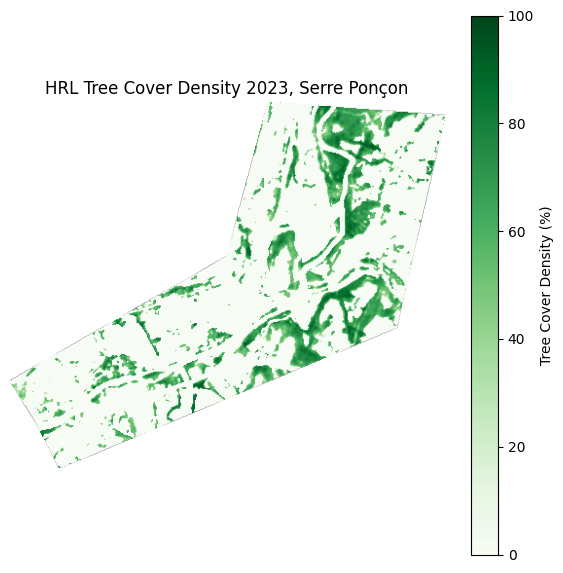

In [11]:
# Mask out pixels with no valid data.
tcd_masked = np.where(tcd_mask > 0, tcd, np.nan)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(tcd_masked, cmap="Greens", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="Tree Cover Density (%)")
ax.set_title("HRL Tree Cover Density 2023, Serre Ponçon")
ax.set_axis_off()
plt.show()

## 5. Fetch the Crop Types Raster (Process API)

The Crop Types layer is **categorical**: each pixel value is a class code, not a continuous measurement. This has two practical consequences.

First, **visualisation** must use a discrete colour map: each class gets its own colour, and we add a legend so the reader can tell wheat from grapes. A continuous colour ramp would be misleading because the numerical distance between class codes carries no physical meaning.

Second, **statistics** are different. We do not compute the mean of class codes (that would be meaningless). Instead we count pixels per class and convert to area percentages — see Section 7.

The class codes follow a hierarchical structure:

- **1110–1150** — Cereals (wheat, barley, rye, oats, maize).
- **1210–1220** — Leafy and legume crops.
- **1310–1320** — Root crops (potato, sugar beet).
- **1410–1440** — Oil and fibre crops (rapeseed, sunflower, soya, flax).
- **2100–2320** — Permanent crops (grapes, olives, fruit trees, nuts).
- **3100–3200** — Unclassified or other arable land.

To make the categorical map readable we build a fixed mapping from class code to colour and to human-readable label, then plot with a `ListedColormap` and a custom legend.


In [12]:
# Process API: fetch the HRL Crop Type (CTY) raster, also as a numpy array.
# Official CLMS HRL Crop Type 2023 class codes -> human-readable name.
CROP_CLASSES = {
    1110: "Wheat",
    1120: "Barley",
    1130: "Maize",
    1140: "Rice",
    1150: "Other Cereals",
    1210: "Fresh Vegetables",
    1220: "Dry Pulses",
    1310: "Potatoes",
    1320: "Sugar Beet",
    1410: "Sunflower",
    1420: "Soybeans",
    1430: "Rapeseed",
    1440: "Flax cotton and hemp",
    2100: "Grapes",
    2200: "Olives",
    2310: "Fruits",
    2320: "Nuts",
    3100: "Unclassified arable crop",
    3200: "Unclassified permanent crop",
}

crop_type_visualization_evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["CTY", "dataMask"],
    output: { bands: 2, sampleType: "FLOAT32" }
  };
}
function evaluatePixel(s) {
  return [s.CTY, s.dataMask];
}
"""

crop_request = SentinelHubRequest(
    evalscript=crop_type_visualization_evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=crop_type_byoc_collection,
            time_interval=("2023-01-01", "2023-12-31"),
        ),
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    geometry=AOI_GEOMETRY,
    resolution=(10, 10),
    config=config,
)

crop_data = crop_request.get_data()[0]
cty = crop_data[..., 0]
cty_mask = crop_data[..., 1]

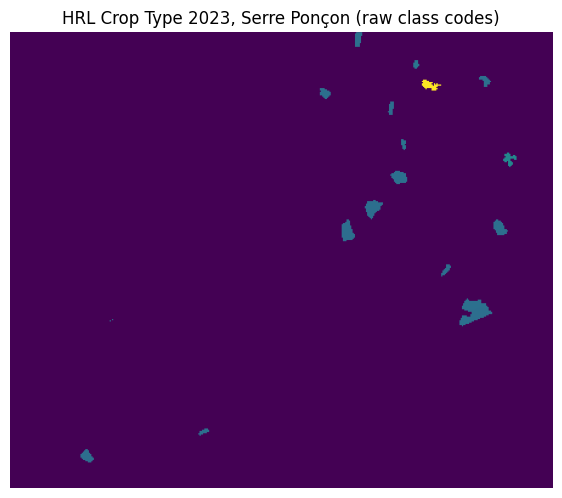

In [15]:
# Display the raw Crop Type raster
fig, ax = plt.subplots(figsize=(7, 7))
plt.imshow(cty)
ax.set_title("HRL Crop Type 2023, Serre Ponçon (raw class codes)")
ax.set_axis_off()
plt.show()

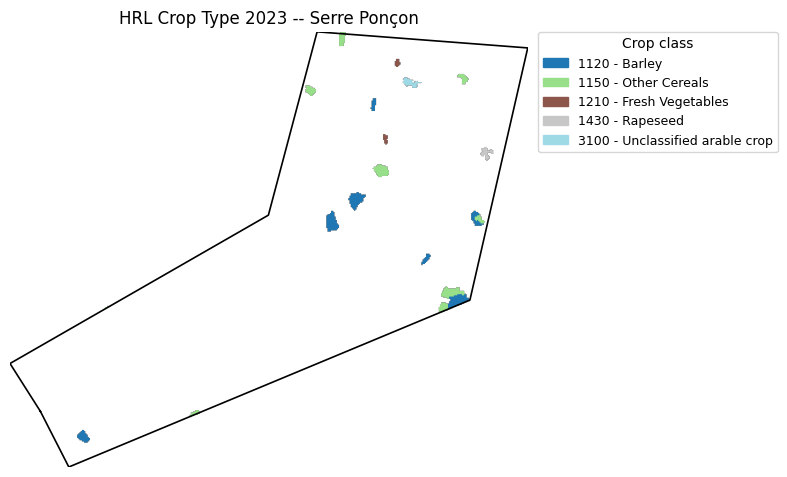

In [13]:
# The official CLMS evalscript treats both 65535 (noData) and 0 ("no crop")
# as excluded. Pixels outside the polygon also have dataMask=0.
cty_masked = np.where((cty_mask > 0) & (cty != 65535) & (cty != 0), cty, np.nan)

# Build a categorical colormap covering only the classes that show up in the AOI.
present_codes = sorted(int(c) for c in np.unique(cty_masked[~np.isnan(cty_masked)]))
base_cmap = plt.get_cmap("tab20", max(len(present_codes), 1))
code_to_color = {code: base_cmap(i) for i, code in enumerate(present_codes)}

# Build an index image: each present code -> small integer index for ListedColormap.
code_to_index = {code: i for i, code in enumerate(present_codes)}
indexed = np.full(cty_masked.shape, np.nan, dtype=float)
for code, idx in code_to_index.items():
    indexed[cty_masked == code] = idx

discrete_cmap = ListedColormap([code_to_color[c] for c in present_codes])
discrete_cmap.set_bad(alpha=0)  # NaN -> transparent (no "blue" fill)

# Render with the bbox in EPSG:3035 metres as the data coords so we can
# draw the polygon outline in its native CRS on top.
xmin, ymin, xmax, ymax = AOI_BBOX
extent = (xmin, xmax, ymin, ymax)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(
    indexed,
    cmap=discrete_cmap,
    vmin=-0.5,
    vmax=len(present_codes) - 0.5,
    extent=extent,
    origin="upper",
)
ax.plot(*AOI_GEOMETRY.geometry.exterior.xy, color="black", linewidth=1.2)
ax.set_aspect("equal")
ax.set_title("HRL Crop Type 2023 -- Serre Ponçon")
ax.set_axis_off()

# Legend with one patch per crop class actually present.
legend_handles = [
    mpatches.Patch(
        color=code_to_color[code],
        label=f"{code} - {CROP_CLASSES.get(code, f'Unknown ({code})')}",
    )
    for code in present_codes
]
ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
    title="Crop class",
)
plt.tight_layout()
plt.show()

## 6. Compute Area Statistics (Statistical API)

The **Statistical API** uses the same building blocks as the Process API: AOI, time range, evalscript... but instead of returning pixel data it returns **aggregated statistics** (mean, standard deviation, min, max, percentiles, optional histograms) over the AOI. For "how much of X is in Y" questions, this is dramatically cheaper than fetching the raster and reducing it locally: no pixels cross the network.

As we would like to derive the proportion of areas with high tree cover density (≥ 75%) as a proxy for runoff mitigation and nitrate retention, the evalscript outputs `1` if `TCD ≥ 75`, otherwise `0`. The `mean` of that binary band is then exactly the **fraction of valid pixels with TCD ≥ 75**. Multiplying by 100 gives the percentage of the AOI covered by dense tree canopy.

This number is precisely the indicator the Zero Pollution workflow uses as a *tree-cover-buffer* predictor of nitrate retention: a higher percentage suggests stronger riparian buffering capacity in the landscape upstream of a water-quality station.

A note on time: the `aggregation_interval` parameter controls how the time range is bucketed. We use `P1Y` (one year) so the request returns a single statistic for 2023. Smaller intervals (`P1M`, `P10D`) would return one row per bucket — useful for time series, overkill here because TCD is an annual product.


In [8]:
# Statistical API: what fraction of the AOI has Tree Cover Density >= 75 %?
# The Statistical API runs an evalscript on the server and returns aggregate
# statistics (mean, stdev, percentiles, ...) instead of pixels. Much cheaper than
# downloading a raster when you only need a number.

tcd_ge_75_evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{ bands: ["TCD", "dataMask"] }],
    output: [
      { id: "tcd_ge_75", bands: 1, sampleType: "FLOAT32" },
      { id: "dataMask",  bands: 1 }
    ],
    mosaicking: "SIMPLE"
  };
}
function evaluatePixel(s) {
  return {
    tcd_ge_75: [s.TCD >= 75 ? 1 : 0],
    dataMask:  [s.dataMask]
  };
}
"""

aggregation = SentinelHubStatistical.aggregation(
    evalscript=tcd_ge_75_evalscript,
    time_interval=("2023-01-01", "2024-01-01"),
    aggregation_interval="P1Y",
    resolution=(10, 10),  # 10 m in EPSG:3035 metres
)

# `calculations` keys must match the evalscript output ids.
calculations = {"tcd_ge_75": {"statistics": {"default": {"percentiles": {"k": [50]}}}}}

tcd_stats_request = SentinelHubStatistical(
    aggregation=aggregation,
    input_data=[SentinelHubStatistical.input_data(tcd_byoc_collection)],
    geometry=AOI_GEOMETRY,
    calculations=calculations,
    config=config,
)

tcd_stats = tcd_stats_request.get_data()[0]

In [9]:
# Drill down into the response to find the mean of our 0/1 indicator.
band_stats = tcd_stats["data"][0]["outputs"]["tcd_ge_75"]["bands"]["B0"]["stats"]
mean_indicator = band_stats["mean"]
sample_count = band_stats["sampleCount"]
no_data_count = band_stats.get("noDataCount", 0)
valid_count = sample_count - no_data_count

pct_high_tcd = 100.0 * mean_indicator
print(f"% of area with Tree Cover Density >= 75 %: {pct_high_tcd:.2f} %")
print(
    f"  sampleCount: {sample_count}  (valid pixels: {valid_count}, noData: {no_data_count})"
)

% of area with Tree Cover Density >= 75 %: 4.76 %
  sampleCount: 168072  (valid pixels: 74583, noData: 93489)


## 7. Crop Type Area Percentages (Statistical API)

In Section 6 we used the Statistical API for a single continuous indicator (mean of a 0/1 mask). For the **categorical** Crop Type layer we can use a different feature of the same API: **histogram aggregation**. The server classifies pixels into bins we define, and returns the per-bin counts -- so a single request gives us the area of every crop class in the AOI without ever moving raster data over the network.

Two design choices in the request below:

- **Bin edges chosen to isolate each class code.** The 19 official crop codes (1110, 1120, ..., 3200) are not evenly spaced, so we centre a bin of width 1 on each code (`code - 0.5` to `code + 0.5`). The "gap" bins between codes will always be empty.
- **`dataMask` set to 0 only for the `65535` noData sentinel.** Pixels with `CTY = 0` ("no crop here" -- water, forest, urban, etc.) are kept in the sample. They fall *below* our smallest bin edge and the API counts them as `underflowCount` -- giving us the **non-agricultural** pixel count for free.

We then plot two things side by side:

- A **bar chart** of the area share of each detected crop class, expressed as a percentage of the agricultural pixels in the AOI (so the dominant crops stand out instead of being dwarfed by water/forest).
- A **pie chart** of agricultural vs non-agricultural pixels, computed as `bin counts` vs `underflowCount`. This single number is the cleanest summary of "how much of this catchment is farmed?" -- directly relevant to the nitrate-input side of the EEA Zero Pollution model.


In [10]:
# Statistical API: per-class crop counts via histogram aggregation,
# plus an agricultural / non-agricultural split for the pie chart.

# Evalscript: pass through the raw CTY value. Mark only the 65535 noData
# sentinel (and pixels outside the polygon) as "no data". Pixels with
# CTY=0 ("no crop here") stay in the sample so the histogram can split
# agricultural vs non-agricultural pixels via underflowCount.
crop_class_evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{ bands: ["CTY", "dataMask"] }],
    output: [
      { id: "crop_class", bands: 1, sampleType: "FLOAT32" },
      { id: "dataMask",  bands: 1 }
    ],
    mosaicking: "SIMPLE"
  };
}
function evaluatePixel(s) {
  const isNoData = s.CTY === 65535 || s.dataMask === 0;
  return {
    crop_class: [s.CTY],
    dataMask:   [isNoData ? 0 : 1]
  };
}
"""

# Bin edges that isolate each crop code in a width-1 bin.
# Between codes we leave wide "gap" bins that should always be empty.
crop_codes_sorted = sorted(CROP_CLASSES.keys())
crop_bin_edges = []
for code in crop_codes_sorted:
    crop_bin_edges.extend([code - 0.5, code + 0.5])

calculations_crop = {
    "crop_class": {
        "histograms": {"default": {"bins": crop_bin_edges}},
        "statistics": {"default": {"percentiles": {"k": [50]}}},
    }
}

crop_aggregation = SentinelHubStatistical.aggregation(
    evalscript=crop_class_evalscript,
    time_interval=("2023-01-01", "2024-01-01"),
    aggregation_interval="P1Y",
    resolution=(10, 10),
)
crop_stats_request = SentinelHubStatistical(
    aggregation=crop_aggregation,
    input_data=[SentinelHubStatistical.input_data(crop_type_byoc_collection)],
    geometry=AOI_GEOMETRY,
    calculations=calculations_crop,
    config=config,
)
crop_stats = crop_stats_request.get_data()[0]

Pixels with valid CTY in AOI: 74583
  agricultural (any crop):      1340 ( 1.80 %)
  non-agricultural (CTY=0):    73243 (98.20 %)


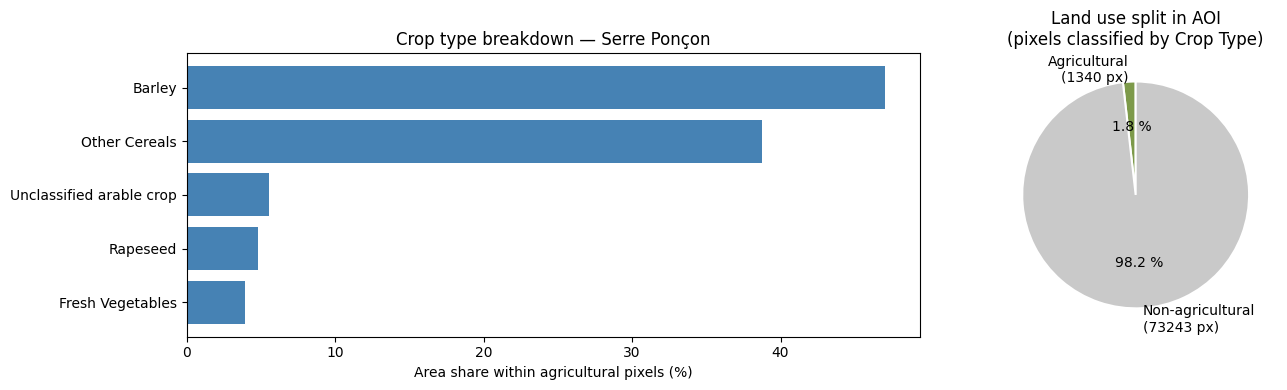

,code,name,n_pixels,area_pct_of_agri
0,1120,Barley,630,47.014925
1,1150,Other Cereals,519,38.731343
2,3100,Unclassified arable crop,74,5.522388
3,1430,Rapeseed,64,4.776119
4,1210,Fresh Vegetables,53,3.955224


In [11]:
# --- Parse the histogram ---------------------------------------------------
out = crop_stats["data"][0]["outputs"]["crop_class"]["bands"]["B0"]
hist = out["histogram"]
non_agri_count = int(hist.get("underflowCount", 0))  # pixels with CTY=0

# Keep only the width-1 bins that isolate a real crop code.
crop_rows = []
for b in hist["bins"]:
    width = b["highEdge"] - b["lowEdge"]
    if abs(width - 1.0) < 0.01:
        code = int(round(b["lowEdge"] + 0.5))
        if code in CROP_CLASSES and b["count"] > 0:
            crop_rows.append((code, CROP_CLASSES[code], int(b["count"])))

agri_count = sum(r[2] for r in crop_rows)
total_classified = agri_count + non_agri_count

crop_area_df = pd.DataFrame(crop_rows, columns=["code", "name", "n_pixels"])
crop_area_df["area_pct_of_agri"] = 100.0 * crop_area_df["n_pixels"] / agri_count
crop_area_df = crop_area_df.sort_values(
    "area_pct_of_agri", ascending=False
).reset_index(drop=True)

print(f"Pixels with valid CTY in AOI: {total_classified}")
print(
    f"  agricultural (any crop):    {agri_count:>6} ({100*agri_count/total_classified:5.2f} %)"
)
print(
    f"  non-agricultural (CTY=0):   {non_agri_count:>6} ({100*non_agri_count/total_classified:5.2f} %)"
)

# --- Plot: bar chart + pie chart side by side -----------------------------
fig, (ax_bar, ax_pie) = plt.subplots(
    1,
    2,
    figsize=(14, max(4, 0.45 * len(crop_area_df))),
    gridspec_kw={"width_ratios": [3, 2]},
)

ax_bar.barh(crop_area_df["name"], crop_area_df["area_pct_of_agri"], color="steelblue")
ax_bar.invert_yaxis()
ax_bar.set_xlabel("Area share within agricultural pixels (%)")
ax_bar.set_title("Crop type breakdown — Serre Ponçon")

ax_pie.pie(
    [agri_count, non_agri_count],
    labels=[
        f"Agricultural\n({agri_count} px)",
        f"Non-agricultural\n({non_agri_count} px)",
    ],
    colors=["#7d9a4a", "#c9c9c9"],
    autopct="%1.1f %%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax_pie.set_title("Land use split in AOI\n(pixels classified by Crop Type)")

plt.tight_layout()
plt.show()

crop_area_df

## 8. Non-Agricultural Land Cover (LCM-10)

In order to characterise non‑agricultural land cover classes (e.g. shrubs, forests, herbaceous vegetation) surrounding monitoring stations, we can use LCM-10.


LCM-10 class codes (pixel value -> label):

| Code | Class                    | Code | Class                  |
|-----:|--------------------------|-----:|------------------------|
|   10 | Tree cover               |   70 | Moss and lichen        |
|   20 | Shrubland                |   80 | Bare / sparse vegetation |
|   30 | Grassland                |   90 | Built-up               |
|   40 | Cropland                 |  100 | Permanent water bodies |
|   50 | Herbaceous wetland       |  110 | Snow and ice           |
|   60 | Mangroves                |  254 | Unclassifiable         |

We fetch the raster via the Process API (same pattern as Crop Type), visualise it with the official LCM-10 palette, and derive a single indicator close to Roger's: the **% of the AOI in non-agricultural natural cover** -- the sum of Tree cover, Shrubland, Grassland, Wetland, Mangroves, Moss/lichen, and Bare/sparse vegetation. High values suggest stronger natural buffering capacity against nutrient runoff.


In [16]:
# Process API: fetch LCM-10 (Land Cover Map at 10 m, Global, Annual).
# We switch to 2020 here because that is the only year currently ingested for
# LCM-10 in CDSE -- the product is described as the "2020 base year".
LCM_COLLECTION_ID = "828f6b20-8ffd-48f8-a1da-fefd271456db"
lcm_byoc_collection = DataCollection.define_byoc(LCM_COLLECTION_ID, name="LCM10_2020")

# Class codes -> human-readable labels (from the official LCM-10 legend).
LCM_CLASSES = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Herbaceous wetland",
    60: "Mangroves",
    70: "Moss and lichen",
    80: "Bare/sparse vegetation",
    90: "Built-up",
    100: "Permanent water bodies",
    110: "Snow and ice",
    254: "Unclassifiable",
}
# Official LCM-10 colours (hex) -- copied from the product evalscript.
LCM_COLORS = {
    10: "#006400",
    20: "#ffbb22",
    30: "#ffff4c",
    40: "#f096ff",
    50: "#0096a0",
    60: "#00cf75",
    70: "#fae6a0",
    80: "#b4b4b4",
    90: "#fa0000",
    100: "#0064c8",
    110: "#f0f0f0",
    254: "#0a0a0a",
}
# Non-agricultural natural-cover classes (Roger's CLCplus indicator).
NON_AGRICULTURAL_CLASSES = {10, 20, 30, 50, 60, 70, 80}

lcm_evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["LCM10", "dataMask"],
    output: { bands: 2, sampleType: "FLOAT32" }
  };
}
function evaluatePixel(s) {
  return [s.LCM10, s.dataMask];
}
"""

lcm_request = SentinelHubRequest(
    evalscript=lcm_evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=lcm_byoc_collection,
            time_interval=("2020-01-01", "2020-12-31"),
        ),
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    geometry=AOI_GEOMETRY,
    resolution=(10, 10),
    config=config,
)

lcm_data = lcm_request.get_data()[0]
lcm = lcm_data[..., 0]
lcm_mask = lcm_data[..., 1]
lcm_masked = np.where((lcm_mask > 0) & (lcm != 255), lcm, np.nan)

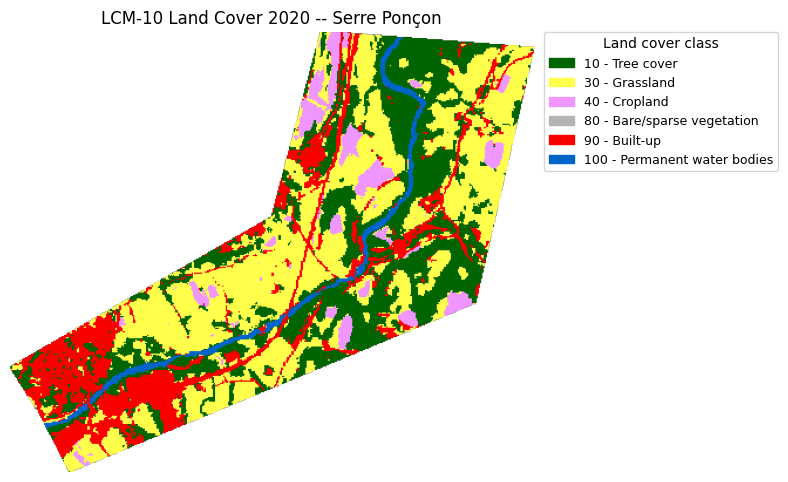

% of AOI in non-agricultural natural cover: 72.75 %
  (sum of classes: [10, 30, 80])


,code,name,n_pixels,area_pct
0,30,Grassland,30450,40.826998
1,10,Tree cover,23795,31.904053
2,90,Built-up,13672,18.331255
3,40,Cropland,4380,5.872652
4,100,Permanent water bodies,2275,3.050293
5,80,Bare/sparse vegetation,11,0.014749


In [17]:
# Discrete visualisation using the official LCM-10 palette.
present_lcm_codes = sorted(int(c) for c in np.unique(lcm_masked[~np.isnan(lcm_masked)]))
lcm_code_to_index = {code: i for i, code in enumerate(present_lcm_codes)}
lcm_indexed = np.full(lcm_masked.shape, np.nan, dtype=float)
for code, idx in lcm_code_to_index.items():
    lcm_indexed[lcm_masked == code] = idx
lcm_cmap = ListedColormap([LCM_COLORS.get(c, "#000000") for c in present_lcm_codes])

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(lcm_indexed, cmap=lcm_cmap, vmin=-0.5, vmax=len(present_lcm_codes) - 0.5)
ax.set_title("LCM-10 Land Cover 2020 -- Serre Ponçon")
ax.set_axis_off()
ax.legend(
    handles=[
        mpatches.Patch(color=LCM_COLORS.get(c), label=f"{c} - {LCM_CLASSES.get(c)}")
        for c in present_lcm_codes
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
    title="Land cover class",
)
plt.tight_layout()
plt.show()

# Per-class areas + the aggregate non-agricultural indicator.
valid_lcm = lcm_masked[~np.isnan(lcm_masked)].astype(np.int64)
total_lcm_pixels = int(valid_lcm.size)
codes, counts = np.unique(valid_lcm, return_counts=True)
lcm_area_df = (
    pd.DataFrame(
        {
            "code": codes.astype(int),
            "name": [LCM_CLASSES.get(int(c), f"Unknown ({int(c)})") for c in codes],
            "n_pixels": counts.astype(int),
            "area_pct": 100.0 * counts / total_lcm_pixels,
        }
    )
    .sort_values("area_pct", ascending=False)
    .reset_index(drop=True)
)

pct_non_agri = (
    100.0 * np.isin(valid_lcm, list(NON_AGRICULTURAL_CLASSES)).sum() / total_lcm_pixels
)
print(f"% of AOI in non-agricultural natural cover: {pct_non_agri:.2f} %")
print(
    f"  (sum of classes: {sorted(NON_AGRICULTURAL_CLASSES & set(int(c) for c in codes))})"
)
lcm_area_df

## 9. Recap: All CLMS-Derived Indicators on One Chart

We have now computed all the **percentage-area indicators** that the EEA Zero Pollution workflow uses CLMS data for, scoped to a single catchment polygon (Lake Serre-Ponçon, ~7.4 km²):

| Indicator | Source layer | Section | API used |
|---|---|---|---|
| % of each crop type in the AOI | HRL Crop Types | §7 | Statistical (histogram) |
| % tree-covered area (TCD ≥ 75 %) | HRL Tree Cover Density | §6 | Statistical (mean of 0/1) |
| % non-agricultural land cover | LCM-10 (proxy for CLCplus Backbone) | §8 | Process + numpy |

The next cell pulls every percentage we already have in memory into a single horizontal bar chart, all expressed as **% of the AOI**, so they are directly comparable. Indicators we could not compute -- *HNV farmland* and *Imperviousness Density* -- are flagged below the chart.

### How quick is this?

The four API calls behind these indicators (one Process call for the TCD raster, one Statistical call for the TCD threshold, one Statistical call for the crop-type histogram, one Process call for LCM-10) typically return in a few seconds each. **Producing all of these zonal indicators for a new monitoring catchment is a sub-minute operation**, which is what makes this approach attractive for scaling to the hundreds or thousands of stations in the EEA water-quality network.

### What you would do next

These percentages are not the end of the workflow, they are its *input*. In a typical pipeline they become **explanatory variables in a statistical analysis** of nitrate concentration:

> *"Linear mixed-effects modelling, combining CLMS-derived indicators (crop types, tree cover, imperviousness, land cover groups) with environmental zones as a random effect, to identify which land-related factors significantly influence observed nitrate concentrations."*

Concretely, one would:

1. **Loop** the request pattern in this notebook over every monitoring station's catchment, producing one row of indicators per station.
2. **Join** that table to the measured nitrate concentrations.
3. **Fit** a linear mixed-effects model where the CLMS percentages are fixed-effect predictors and biogeographical region is a random effect.
4. **Interpret** which land-cover variables carry significant explanatory weight, e.g. confirming that high TCD catchments retain more nitrate while heavily-cropped catchments leak more.

The expensive part of that pipeline: *getting consistent, comparable land-cover indicators across hundreds of catchments*, is exactly what we have just demonstrated.


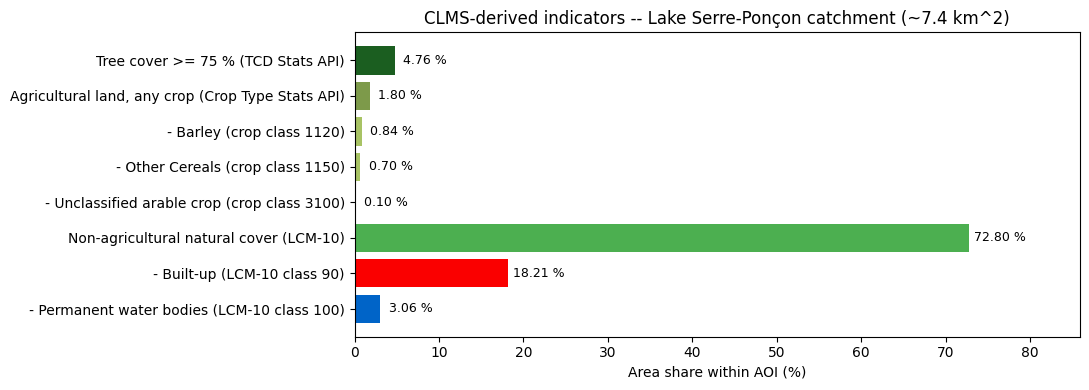

,Indicator,Percent of AOI
0,Tree cover >= 75 % (TCD Stats API),4.758457
1,"Agricultural land, any crop (Crop Type Stats API)",1.796656
2,- Barley (crop class 1120),0.844697
3,- Other Cereals (crop class 1150),0.695869
4,- Unclassified arable crop (crop class 3100),0.099218
5,Non-agricultural natural cover (LCM-10),72.802885
6,- Built-up (LCM-10 class 90),18.205046
7,- Permanent water bodies (LCM-10 class 100),3.055467


In [14]:
# Build a single table of every CLMS-derived percentage we have in memory,
# all expressed as "% of the AOI", and plot them on one horizontal bar chart.

# Total polygon pixel count from each Stats API call. They differ by <1 %
# because of independent rasterisation per request -- we keep each indicator
# on its own denominator and report it as a percentage.
agri_total = agri_count + non_agri_count  # CTY-classifiable pixels in the polygon

# Pull each indicator into a (label, percent_of_AOI, colour) tuple.
recap_rows = []

# 1) Tree Cover Density >= 75 % (Section 6, Stats API)
recap_rows.append(("Tree cover >= 75 % (TCD Stats API)", pct_high_tcd, "#1b5e20"))

# 2) Total agricultural land + top 3 crop types (Section 7, Stats API histogram)
recap_rows.append(
    (
        "Agricultural land, any crop (Crop Type Stats API)",
        100.0 * agri_count / agri_total,
        "#7d9a4a",
    )
)
for _, row in crop_area_df.head(3).iterrows():
    pct_of_aoi = 100.0 * row["n_pixels"] / agri_total
    recap_rows.append(
        (f"   - {row['name']} (crop class {int(row['code'])})", pct_of_aoi, "#a8c364")
    )

# 3) Non-agricultural natural cover and key LCM-10 classes (Section 8, Process API)
recap_rows.append(("Non-agricultural natural cover (LCM-10)", pct_non_agri, "#4caf50"))
for lcm_code in (90, 100):  # Built-up, Permanent water bodies
    sub = lcm_area_df[lcm_area_df["code"] == lcm_code]
    if len(sub):
        recap_rows.append(
            (
                f"   - {LCM_CLASSES[lcm_code]} (LCM-10 class {lcm_code})",
                float(sub["area_pct"].iloc[0]),
                LCM_COLORS[lcm_code],
            )
        )

recap_df = pd.DataFrame(recap_rows, columns=["Indicator", "Percent of AOI", "Color"])

fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(recap_df))))
bars = ax.barh(
    recap_df["Indicator"], recap_df["Percent of AOI"], color=recap_df["Color"]
)
ax.invert_yaxis()
ax.set_xlabel("Area share within AOI (%)")
ax.set_title("CLMS-derived indicators -- Lake Serre-Ponçon catchment (~7.4 km^2)")
ax.set_xlim(0, max(recap_df["Percent of AOI"]) * 1.18)
for bar, pct in zip(bars, recap_df["Percent of AOI"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:5.2f} %",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

recap_df.drop(columns="Color")

## 10. Try It Yourself: What Kind of Forest Is in the AOI?

So far we know that **4.76 %** of the Serre-Ponçon catchment has a Tree Cover Density of at least 75 % (Section 6) and **22 %** of the AOI is forested in some form (broadleaved + coniferous, derived from the LCM-10 *Tree cover* class in Section 8). A natural follow-up question for an alpine catchment: **what kind of forest is it -- broadleaved or coniferous?**

CLMS publishes that exact split as the **HRL Forest Type (FTY)** layer:

- **HRL Forest Type (FTY)** -- see [the product page on CDSE docs](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/clms/land-cover-and-land-use-mapping/tree-cover-and-forests/forest-type/forest-type/clms_vlcc_forest-type_europe_10m_3yearly_v1.html).
  - `collection_id`: `4d1aad1a-f800-43c5-87d0-5565a9a31c12`
  - Band: `FTY`, three integer classes — **0 = non-forest, 1 = broadleaved forest, 2 = coniferous forest**. NoData is 255.
  - Native resolution: 10 m. Cadence: 3-yearly (2018, 2021).

The next cell wires up exactly the same Statistical-API-with-histogram pattern we used for Crop Types in Section 7, but applied to FTY. Try changing `MY_YEAR` between **2018** and **2021** to see whether the broadleaved/coniferous split has shifted at Serre-Ponçon over those three years.

### Things to try after that

- **Swap the AOI**: drop a different polygon into `data/serre_poncon_3035.geojson` (or load any other GeoJSON) and re-run the whole notebook. The same code will compute TCD, crop type, LCM-10, and FTY indicators for the new catchment.
- **Replace the bbox with a buffered point**: build a `shapely.Point` for a real water-monitoring station, project to a metric CRS, call `.buffer(1000)`, and pass the resulting geometry to Sentinel Hub.
- **Loop** over many monitoring stations and assemble the indicators into a single `pandas.DataFrame` for downstream modelling.
- **Add another CLMS layer** -- e.g. the *Dominant Leaf Type Change* layer for forest dynamics, or the *Grassland* layer for pasture intensity. The pattern is identical: change the `collection_id`, adjust the histogram bins or threshold, and re-run.

### Further reading

- CDSE documentation: https://documentation.dataspace.copernicus.eu/
- Sentinel Hub Process API: https://docs.sentinel-hub.com/api/latest/api/process/
- Sentinel Hub Statistical API: https://docs.sentinel-hub.com/api/latest/api/statistical/
- Custom scripts (evalscripts) catalogue: https://custom-scripts.sentinel-hub.com/
- CLMS HRL Tree Cover and Forests: https://land.copernicus.eu/en/products/high-resolution-layer-forests-and-tree-cover


FTY for Serre Ponçon, year 2018:
  total valid pixels in AOI: 74583
    0  Non-forest     58003 px  (77.77 % of AOI)
    1  Broadleaved     6993 px  ( 9.38 % of AOI)
    2  Coniferous      9587 px  (12.85 % of AOI)
  Forest total (broadleaved + coniferous): 22.23 % of AOI
    -> within forest: 42.2 % broadleaved / 57.8 % coniferous


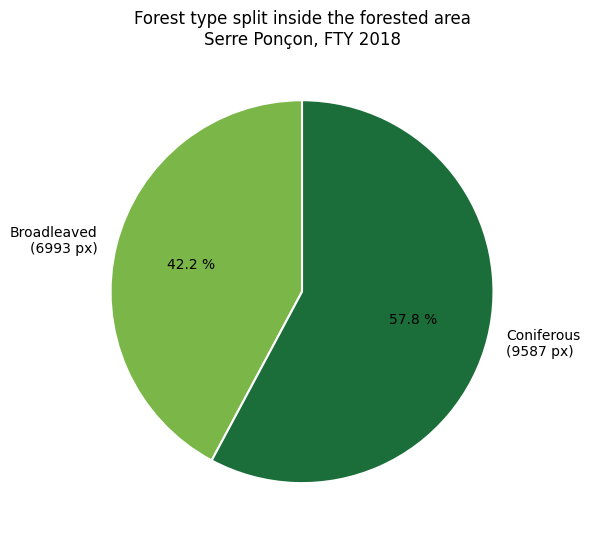

In [15]:
# === EDIT THIS TO PICK A YEAR ===
MY_YEAR = 2018  # FTY is published 3-yearly. Available years in CDSE: 2018, 2021.
# ================================

# HRL Forest Type (FTY): 0 = non-forest, 1 = broadleaved, 2 = coniferous, 255 = noData.
FTY_COLLECTION_ID = "4d1aad1a-f800-43c5-87d0-5565a9a31c12"
fty_byoc_collection = DataCollection.define_byoc(FTY_COLLECTION_ID, name="HRL_FTY")
FTY_CLASSES = {0: "Non-forest", 1: "Broadleaved", 2: "Coniferous"}
FTY_COLORS = {0: "#d9d9d9", 1: "#7ab648", 2: "#1b6e3a"}

# --- Stats API: histogram aggregation gives one bin per class --------------
# We reuse the exact same pattern as the Crop Type cell (§7): output the raw
# class value, mask only the noData sentinel (255), and let bin edges of
# [-0.5, 0.5, 1.5, 2.5] put each class in its own bin.
fty_evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{ bands: ["FTY", "dataMask"] }],
    output: [
      { id: "fty", bands: 1, sampleType: "FLOAT32" },
      { id: "dataMask", bands: 1 }
    ],
    mosaicking: "SIMPLE"
  };
}
function evaluatePixel(s) {
  const isNoData = s.FTY === 255 || s.dataMask === 0;
  return { fty: [s.FTY], dataMask: [isNoData ? 0 : 1] };
}
"""

fty_calculations = {"fty": {"histograms": {"default": {"bins": [-0.5, 0.5, 1.5, 2.5]}}}}
fty_aggregation = SentinelHubStatistical.aggregation(
    evalscript=fty_evalscript,
    time_interval=(f"{MY_YEAR}-01-01", f"{MY_YEAR + 1}-01-01"),
    aggregation_interval="P1Y",
    resolution=(10, 10),
)
fty_request = SentinelHubStatistical(
    aggregation=fty_aggregation,
    input_data=[SentinelHubStatistical.input_data(fty_byoc_collection)],
    geometry=AOI_GEOMETRY,
    calculations=fty_calculations,
    config=config,
)
fty_resp = fty_request.get_data()[0]

# --- Parse the histogram ---------------------------------------------------
hist = fty_resp["data"][0]["outputs"]["fty"]["bands"]["B0"]["histogram"]
fty_counts = {}
for b in hist["bins"]:
    code = int(round((b["lowEdge"] + b["highEdge"]) / 2))
    fty_counts[code] = int(b["count"])

total_pixels = sum(fty_counts.values())
forest_pixels = fty_counts.get(1, 0) + fty_counts.get(2, 0)

print(f"FTY for Serre Ponçon, year {MY_YEAR}:")
print(f"  total valid pixels in AOI: {total_pixels}")
for code, label in FTY_CLASSES.items():
    n = fty_counts.get(code, 0)
    print(
        f"    {code}  {label:<12}  {n:>6} px  ({100 * n / total_pixels:5.2f} % of AOI)"
    )
print(
    f"  Forest total (broadleaved + coniferous): {100 * forest_pixels / total_pixels:.2f} % of AOI"
)
if forest_pixels:
    pct_broad = 100 * fty_counts.get(1, 0) / forest_pixels
    pct_con = 100 * fty_counts.get(2, 0) / forest_pixels
    print(
        f"    -> within forest: {pct_broad:.1f} % broadleaved / {pct_con:.1f} % coniferous"
    )

# --- Plot: pie of the forested fraction (broadleaved vs coniferous) -------
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [fty_counts.get(1, 0), fty_counts.get(2, 0)],
    labels=[
        f"Broadleaved\n({fty_counts.get(1, 0)} px)",
        f"Coniferous\n({fty_counts.get(2, 0)} px)",
    ],
    colors=[FTY_COLORS[1], FTY_COLORS[2]],
    autopct="%1.1f %%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title(f"Forest type split inside the forested area\nSerre Ponçon, FTY {MY_YEAR}")
plt.tight_layout()
plt.show()